In [1]:
import numpy as np

from rose.data import training_data
from rose.viz import plot_prediction_scatter

In [2]:
X_train, y_train = training_data(N=256, seed=37)
X_test, y_test = training_data(N=1_000, seed=42)

In [3]:
X2 = X_train.flatten()[:, np.newaxis]


@np.vectorize
def is_odd(n):
    return int(n % 2 != 0)


@np.vectorize
def is_prime(n):
    if n < 2:
        return 0
    for i in range(2, int(np.sqrt(n)) + 1):
        if n % i == 0:
            return 0
    return 1


def augment(X):
    features = np.hstack([X, is_odd(X), X * is_odd(X)])
    bias = np.ones((X.shape[0], 1), dtype=X.dtype)
    return np.hstack([features, bias])


X2 = augment(X2)

In [4]:
X2[:10, :]

array([[4, 0, 0, 1],
       [5, 1, 5, 1],
       [4, 0, 0, 1],
       [5, 1, 5, 1],
       [6, 0, 0, 1],
       [3, 1, 3, 1],
       [4, 0, 0, 1],
       [4, 0, 0, 1],
       [3, 1, 3, 1],
       [6, 0, 0, 1]])

In [5]:
y2 = y_train.repeat(5)
print(X2.shape, y2.shape)

solution, residuals, rank, singular_values = np.linalg.lstsq(X2, y2, rcond=None)
solution

(1280, 4) (1280,)


array([-0.0506753 , -0.97775392,  0.96431885,  4.43265294])

miscalibration: -1.099


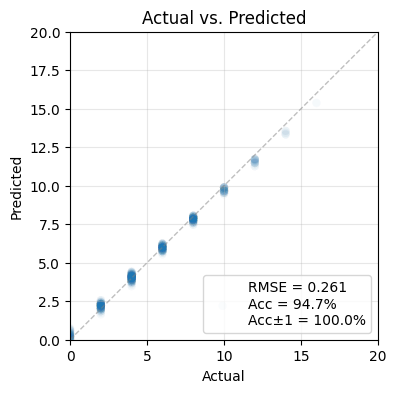

In [6]:
def predict(X):
    y_pred = []
    for i in range(X.shape[0]):
        row = X[i]
        row[:, np.newaxis]
        X_augmented = augment(row[:, np.newaxis])
        y_pred.append((X_augmented[:, :-1] @ solution[:-1]).sum())
    return np.array(y_pred)


y_hat_test = predict(X_test)
offset = y_hat_test.mean() - y_test.mean()
print(f"miscalibration: {offset:0.3f}")
y_hat_test = y_hat_test - offset

plot_prediction_scatter(
    y_test,
    y_hat_test,
    title="Actual vs. Predicted",
)